# Pneumonia Detection from Chest X-Ray Images using CNN

In [6]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
# importing the required libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import os

In [8]:
# setting random seed so results are reproducible
tf.random.set_seed(42)
np.random.seed(42)

In [9]:
# paths to the dataset folders
base_dir = 'chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

In [10]:
# image size and batch size for training
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

In [11]:
# applying augmentation to training data to improve generalization
# val and test data only needs rescaling
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

In [12]:
# loading images from the directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['NORMAL', 'PNEUMONIA']
)
val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['NORMAL', 'PNEUMONIA']
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=['NORMAL', 'PNEUMONIA'],
    shuffle=False
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [13]:
# building the CNN model
# 3 conv layers to extract features, then dense layers for classification
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

c:\Users\varsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
# compiling with binary crossentropy since this is a 2-class problem
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# training the model
# class_weight used because pneumonia images are more than normal in the dataset

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight={0: 1.0, 1: 1.5}
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - accuracy: 0.7715 - loss: 0.5821 - val_accuracy: 0.8125 - val_loss: 0.5701
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 165s 1s/step - accuracy: 0.8426 - loss: 0.3932 - val_accuracy: 0.6875 - val_loss: 0.9461
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 168s 1s/step - accuracy: 0.8813 - loss: 0.3185 - val_accuracy: 0.8125 - val_loss: 0.5193
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8901 - loss: 0.3015 - val_accuracy: 0.6250 - val_loss: 0.8473
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 218s 1s/step - accuracy: 0.8928 - loss: 0.2940 - val_accuracy: 0.7500 - val_loss: 0.4896
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9022 - loss: 0.2676 - val_accuracy: 0.7500 - val_loss: 0.4608
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 228s 1s/step - accuracy: 0.9109 - loss: 0.2602 - val_accuracy: 0.6875 - val_loss: 0.6883
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 230s 1s/step - accuracy: 0.9153 - loss: 0.2377 - val_accu

In [16]:
# checking accuracy on the test set
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 666ms/step - accuracy: 0.7628 - loss: 0.5078
Test Accuracy: 0.7628


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 611ms/step


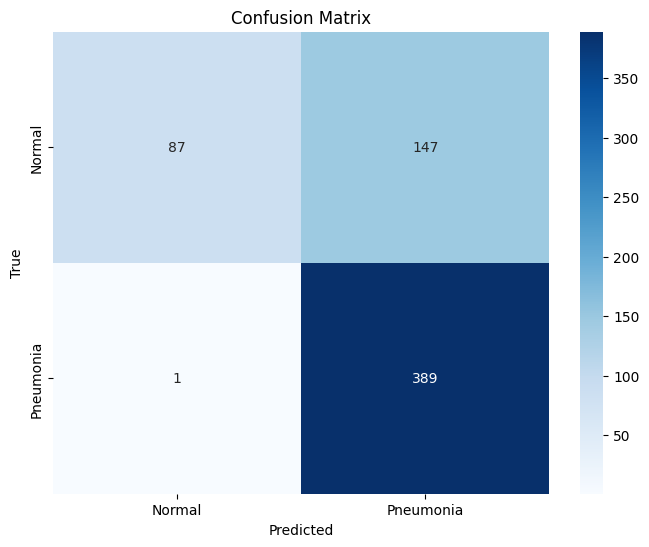

In [17]:
# confusion matrix to see where the model is making errors
y_pred = (model.predict(test_generator) > 0.5).astype(int)
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [18]:
# precision, recall and f1 score for each class
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

              precision    recall  f1-score   support

      Normal       0.99      0.37      0.54       234
   Pneumonia       0.73      1.00      0.84       390

    accuracy                           0.76       624
   macro avg       0.86      0.68      0.69       624
weighted avg       0.82      0.76      0.73       624



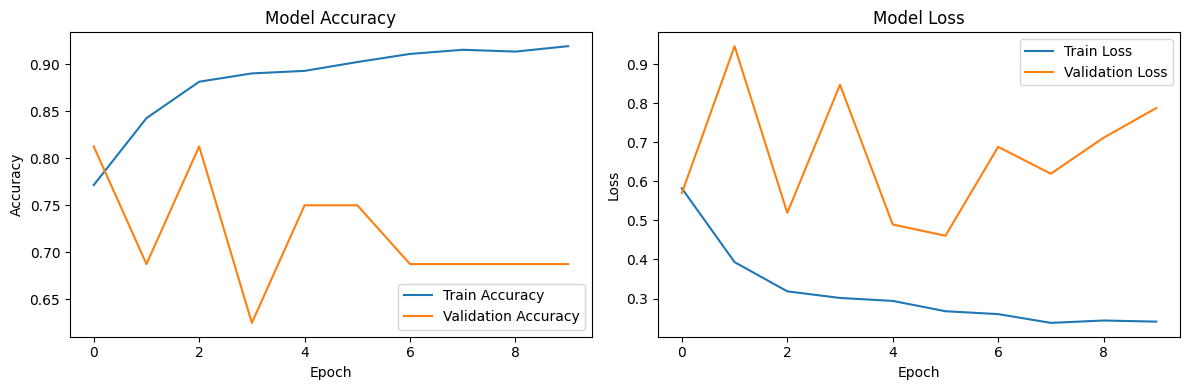

In [19]:
# plotting accuracy and loss over each epoch to see how training went
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# saving the model
model.save('pneumonia_cnn_model.h5')

In [26]:
# loading the saved model to run predictions on new images
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image

model = load_model('pneumonia_cnn_model.h5')

image_folder = os.path.join(test_dir, 'NORMAL')
image_files = [os.path.join(image_folder, f) for f in os.listdir(image_folder)[:20]]



class_names = ['Normal', 'Pneumonia']
results = []

for fname in image_files:
    img = image.load_img(fname, target_size=(150, 150))
    x = image.img_to_array(img) / 255.0
    x = np.expand_dims(x, axis=0)
    score = float(model.predict(x, verbose=0)[0][0])
    label = class_names[int(score > 0.5)]
    results.append((fname, label, score))
    print(f"{fname}: {label} ({score:.4f})")

chest_xray\test\NORMAL\IM-0001-0001.jpeg: Pneumonia (0.6866)
chest_xray\test\NORMAL\IM-0003-0001.jpeg: Pneumonia (0.8303)
chest_xray\test\NORMAL\IM-0005-0001.jpeg: Pneumonia (0.7516)
chest_xray\test\NORMAL\IM-0006-0001.jpeg: Pneumonia (0.5641)
chest_xray\test\NORMAL\IM-0007-0001.jpeg: Normal (0.4203)
chest_xray\test\NORMAL\IM-0009-0001.jpeg: Normal (0.4620)
chest_xray\test\NORMAL\IM-0010-0001.jpeg: Pneumonia (0.7540)
chest_xray\test\NORMAL\IM-0011-0001-0001.jpeg: Pneumonia (0.6160)
chest_xray\test\NORMAL\IM-0011-0001-0002.jpeg: Pneumonia (0.8073)
chest_xray\test\NORMAL\IM-0011-0001.jpeg: Pneumonia (0.7726)
chest_xray\test\NORMAL\IM-0013-0001.jpeg: Normal (0.4606)
chest_xray\test\NORMAL\IM-0015-0001.jpeg: Pneumonia (0.8326)
chest_xray\test\NORMAL\IM-0016-0001.jpeg: Pneumonia (0.5731)
chest_xray\test\NORMAL\IM-0017-0001.jpeg: Pneumonia (0.5960)
chest_xray\test\NORMAL\IM-0019-0001.jpeg: Pneumonia (0.6738)
chest_xray\test\NORMAL\IM-0021-0001.jpeg: Pneumonia (0.7731)
chest_xray\test\NORMAL\

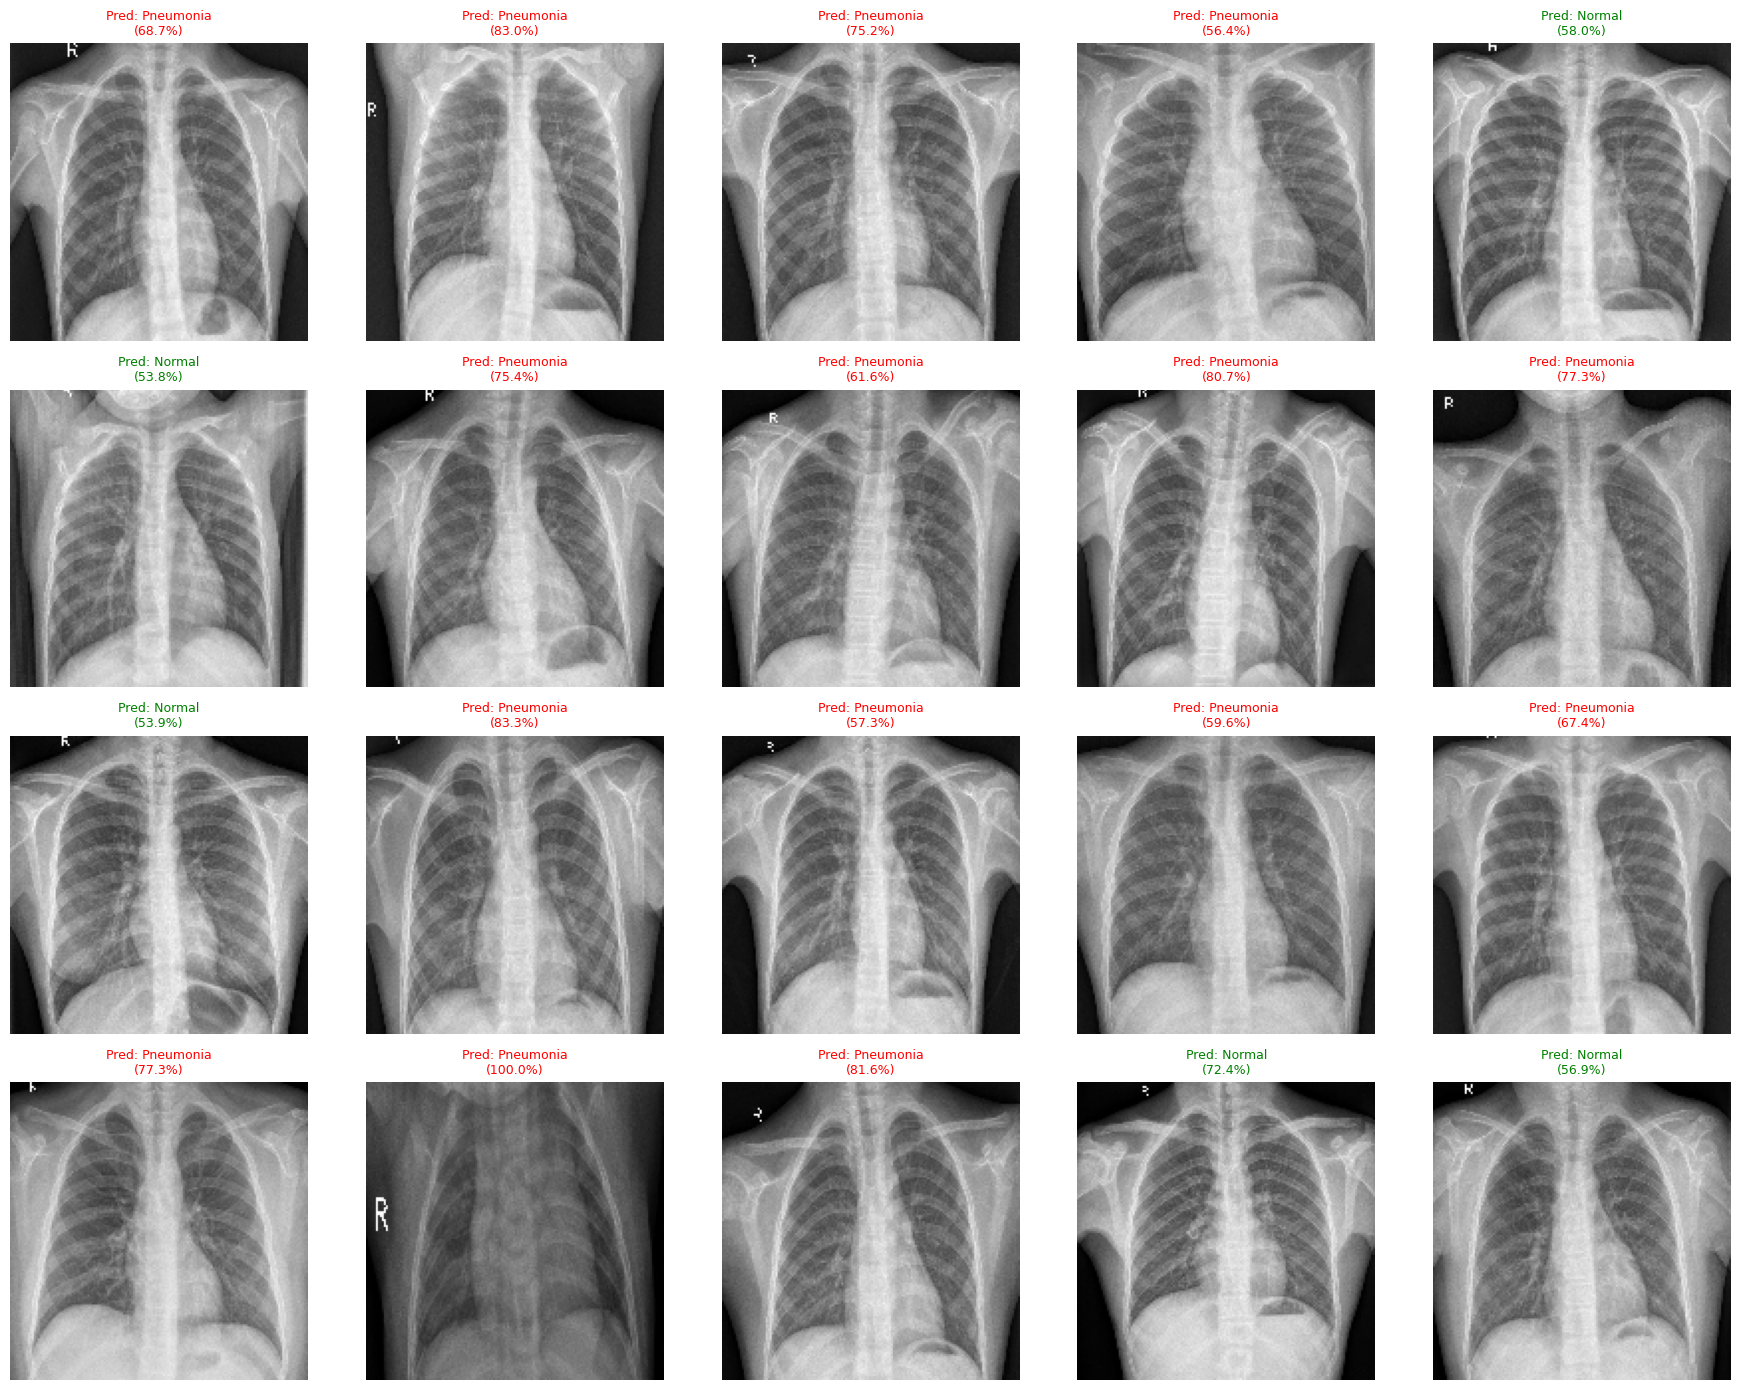

In [27]:
# displaying the prediction result on each image
plt.figure(figsize=(18, 14))
for idx, (fname, label, score) in enumerate(results):
    plt.subplot(4, 5, idx + 1)
    img = image.load_img(fname, target_size=(150, 150))
    plt.imshow(img)
    color = 'red' if label == 'Pneumonia' else 'green'
    conf = score if score > 0.5 else 1 - score
    plt.title(f"Pred: {label}\n({conf*100:.1f}%)", color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()